<a href="https://colab.research.google.com/github/Manar-00/ML-projects/blob/main/breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# منار تركي أحمد -شعبة 2

In [ ]:
# import the important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import Binarizer
from sklearn.metrics import roc_curve, auc

In [ ]:
## evrything is good here but I could not get the data within labele and I try to labale it but it dose not work with me
#df_cancer = pd.read_csv('wdbc.data', header=None)
#df_cancer.to_csv('wdbc.csv', index=False)
#print(df_cancer.head())
#print(df_cancer.info())
#print(df_cancer.describe())

In [ ]:
# so I import the data using this code
# I want to drop the ID coulm (it maybe overfit the model) and encooding the target (the models exsapt only num values) but this steps well done befor in the data, so no need
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df['target'] = data.target

print(df.head())
print(df.info())
print(df.describe())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [ ]:
# Features (X) and target (y)
X = df.drop(columns=['target']).to_numpy()
y = df['target'].to_numpy()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=0, stratify=y
)

model1:
Predicted labels: [0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 1
 0 1 0 0 0 1 0 1 0 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 0 0 0 0 1 1 0 1 1
 1 1 1 0 0 1 1 1 1 0 0 1 0 0 0 0 1 1 1 1 1 0 0 1 0 0 0 1 1 0 1 0 1 0 1 1 1
 0 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 0 1 1
 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1]
Accuracy: 0.9590643274853801

Classification Report:
               precision    recall  f1-score   support

   malignant       0.94      0.95      0.95        64
      benign       0.97      0.96      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



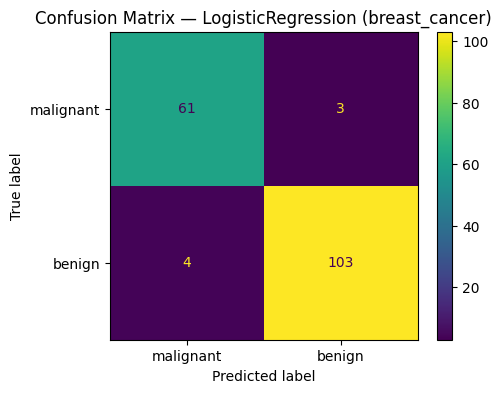

In [ ]:
# LogisticRegression
# I Standardize the data to incares the performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model building and training for LogisticRegression
model1 = LogisticRegression(max_iter=2600)
model1.fit(X_train_scaled, y_train)


print("model1:")
# Make Predictions for model1 (LogisticRegression)
y_pred1= model1.predict(X_test_scaled)
print("Predicted labels:", y_pred1)

# Evaluate the Model1 for (LogisticRegression)
accuracy = accuracy_score(y_test, y_pred1)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred1, target_names=['malignant', 'benign']))

# Confusion Matrix for LogisticRegression
labels = list(data.target_names)  # ['malignant', 'benign']
cm = confusion_matrix(y_test, y_pred1)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax)
plt.title("Confusion Matrix — LogisticRegression (breast_cancer)")
plt.show()

model2:
Predicted labels: [0 1 0 0 0 1 0 0 0 0 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 1 0 1 0 0 1 0 1 1 0 1
 0 1 0 0 0 1 0 1 0 0 1 1 1 1 0 1 0 1 1 0 1 1 1 1 1 0 0 0 0 0 0 0 1 1 0 1 1
 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 0 1 0 0 1 1 1 0 1 1 1 0 1 1 1
 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 0 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1]
Accuracy: 0.9239766081871345

Classification report:

              precision    recall  f1-score   support

   Malignant       0.90      0.89      0.90        64
      Benign       0.94      0.94      0.94       107

    accuracy                           0.92       171
   macro avg       0.92      0.92      0.92       171
weighted avg       0.92      0.92      0.92       171



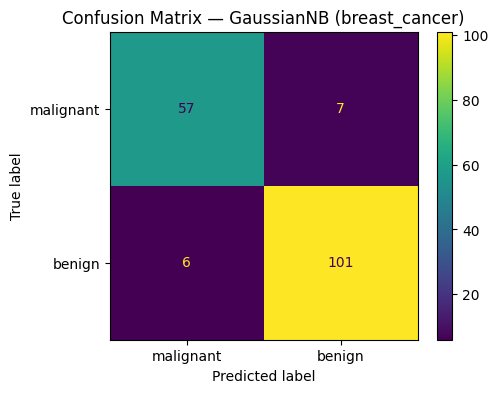

In [ ]:
# Model building and training for GaussianNB
model2 = GaussianNB()
model2.fit(X_train, y_train)

print("model2:")
# Make Predictions for model2 (GaussianNB)
y_pred2 = model2.predict(X_test)
print("Predicted labels:", y_pred2)

# Evaluate the Model2 for (GaussianNB)
accuracy2 = accuracy_score(y_test, y_pred2)
print("Accuracy:", accuracy2)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred2, target_names=["Malignant", "Benign"]))

# Confusion Matrix for GaussianNB
labels = list(data.target_names)  # ['malignant', 'benign']
cm = confusion_matrix(y_test, y_pred2)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax)
plt.title("Confusion Matrix — GaussianNB (breast_cancer)")
plt.show()

model3:
Predicted labels: [1 1 0 0 0 1 0 0 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0 0
 0 1 0 0 0 1 0 1 0 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 1 1
 1 1 0 0 1 1 1 1 1 0 0 1 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 1 1 0 1 1 1 0 1 0 1
 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 0 1 1 0 1 0 1 0 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1]
Accuracy: 0.8421052631578947

Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.79      0.78      0.79        64
           1       0.87      0.88      0.87       107

    accuracy                           0.84       171
   macro avg       0.83      0.83      0.83       171
weighted avg       0.84      0.84      0.84       171



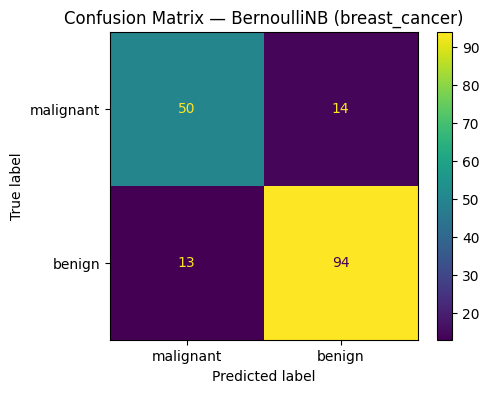

In [ ]:
# BernoulliNB
#Determine the Threshold Value for Binarization
# We use the median of ALL training features as a robust common threshold
threshold_value = np.median(X_train.flatten())

#Initialize and Fit the Binarizer
# The Binarizer transforms values: 1 if > threshold, 0 if <= threshold
binarizer = Binarizer(threshold=threshold_value)

#Apply Binarization
# Fit and transform the training data and teasting data
X_train_binary = binarizer.fit_transform(X_train)
X_test_binary = binarizer.transform(X_test)


# Model building and training for BernoulliNB
model3 = BernoulliNB()
model3.fit(X_train_binary, y_train)

print("model3:")
#Make Predictions for model3 (BernoulliNB)
y_pred3 = model3.predict(X_test_binary)
y_proba3 = model3.predict_proba(X_test_binary)[:, 1]
print("Predicted labels:", y_pred3)

#Evaluate the Model2 for (BernoulliNB)
accuracy3 = accuracy_score(y_test, y_pred3)
print("Accuracy:", accuracy3)

print("\nClassification Report (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred3, zero_division=0))

# Confusion Matrix for BernoulliNB
labels = list(data.target_names)  # ['malignant', 'benign']
cm = confusion_matrix(y_test, y_pred3)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax)
plt.title("Confusion Matrix — BernoulliNB (breast_cancer)")
plt.show()

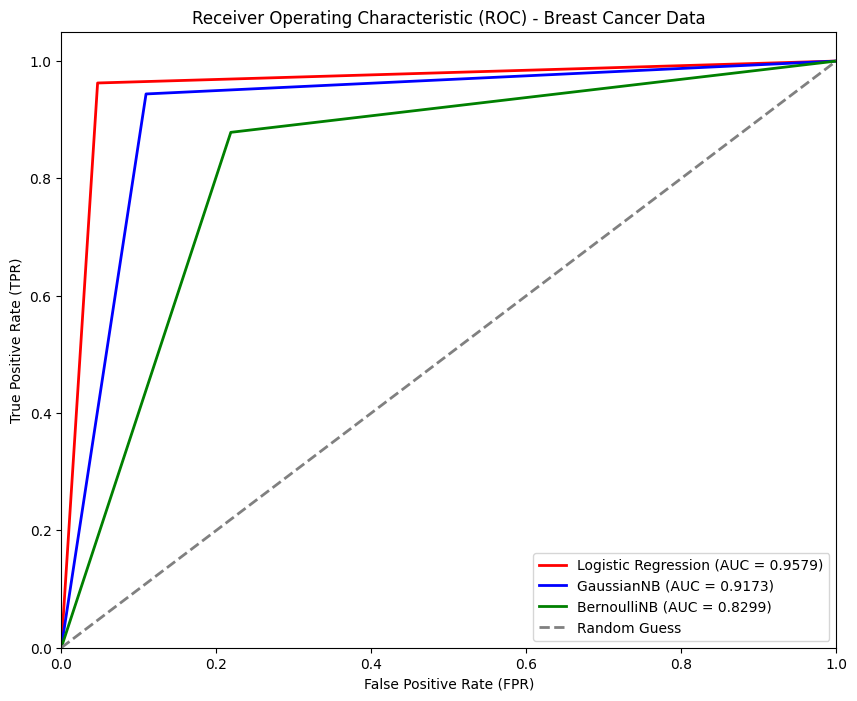

In [ ]:
#plot ROC for all models
fpr_model1, tpr_model1, thresholds_model1 = roc_curve(y_test, y_pred1)
roc_auc_model1 = auc(fpr_model1, tpr_model1)

fpr_model2, tpr_model2, thresholds_model2 = roc_curve(y_test, y_pred2)
roc_auc_model2 = auc(fpr_model2, tpr_model2)

fpr_model3, tpr_model3, thresholds_model3 = roc_curve(y_test, y_pred3)
roc_auc_model3 = auc(fpr_model3, tpr_model3)

plt.figure(figsize=(10, 8))
plt.plot(fpr_model1, tpr_model1, color='red', lw=2,
         label='Logistic Regression (AUC = %0.4f)' % roc_auc_model1)
plt.plot(fpr_model2, tpr_model2, color='blue', lw=2,
         label='GaussianNB (AUC = %0.4f)' % roc_auc_model2)
plt.plot(fpr_model3, tpr_model3, color='green', lw=2,
         label='BernoulliNB (AUC = %0.4f)' % roc_auc_model3)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) - Breast Cancer Data')
plt.legend(loc="lower right")

Comparative Analaysis:
1. From my experiment, I obtained the highest performance with the Logistic model, followed by Gaussian, and finally Bernoulli. The reason is that Logistic Regression handles numerical data very well, especially data that can be linearly separated. Since the data was of this type, the logistic model was able to work with continuous numbers and represent or separate the boundaries between the classes.
Gaussian also works well with numerical data, but it assumes that the features are independent from each other, which is not true for the breast cancer data because the features were correlated. However, it still gave fairly good results.
Bernoulli assumes that each feature is binary, either 0 or 1, so the model calculates the probability that (0 or 1). But the problem is that the breast cancer data is continuous and not binary, and when I converted it, I had to lose part of the precise information, leading to lower accuracy results.

2. The given data consisted of numerical columns and real values, meaning they were not integers or binary. Most of the columns were highly correlated and influenced each other. Also, the target column contained two clearly separated classes, and the data was organized, clean, and ready to use, which is very good. The data was almost normally distributed, and there was no noticeable imbalance. All these factors affected the models as follows:
The Logistic model was able to separate the two classes linearly and learned and predicted very well because the data type was perfectly suitable for it. Also, when I applied standardization, all the columns became balanced, which made it easier for the model to learn the true patterns.
The Gaussian model, although it also works well with numerical data, had a medium or good performance because it assumes that the features are independent from each other, which affected its accuracy since the data was highly correlated and most columns were not independent. Also, the data distribution was not perfectly normal, so the model lost some accuracy.
The Bernoulli model depends on binary data, meaning the presence or absence of a feature, which contradicts the actual type of the data. Therefore, when converting the data, some details were lost, leading to lower accuracy.
the data type and its distribution were suitable for the Logistic model, close to the Gaussian, but not suitable for the Bernoulli model.

3. Before cleaning and preparing the data, I explored it and found that there were no missing values or any need for conversion — the data was excellent. However, there were two steps I wanted to perform. The first was deleting the ID column. This column does not contain any learnable or useful information for training and could cause overfitting or slow down performance. Since it does not include any information related to tumor diagnosis, I wanted to remove it.
The second step was to convert the target column because the models do not handle object values during training; they must be numerical. But when I import the dataset, I discovered that these two steps had already been done.
In addition, before training the Logistic model, I applied standardization, which improved the accuracy and performance (I tried it before standardization and got about 93% accuracy). The other models do not require standardization, and it may even affect their learning and prediction performance.

4. For the breast cancer data, I highly recommend using the Logistic Regression model. It gave high and satisfying performance and results and was very suitable for the data, as it was able to learn and predict excellently. Since the data was continuous, numerical, and linearly separable, it is the type of data that suits Logistic Regression.